# Configuration

In [ ]:
dataset_paths = {
    "Dataset_A": "./ASL_Dataset_A",
    "Dataset_B": "./ASL_Dataset_B",
    "Dataset_C": "./ASL_Dataset_C",
}

sampling_fractions = {
    "Dataset_A": 0.2,
    "Dataset_B": 0.2,
    "Dataset_C": 0.4,
}

image_size = (64, 64)  # H,W
use_rgb = True
batch_size = 64

train_frac = 0.70
val_frac = 0.15
test_frac = 0.15

import torch as _torch
device = "cuda" if _torch.cuda.is_available() else "cpu"

hyperparams = {
    "num_epochs":60,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "batch_size": batch_size,
    "save_model_path": "./merged_asl_model.pth",
    "random_seed": 42,
}

This is our project configurtion. We are using Dataset_A, Dataset_B and Dataset_C for for our merged ASL dataset. We take fraction from each of the datasests, becouse we want diverse data. The split is 70:15:15 for train, validation and test sets respectively. We train and test with RGB. The hyperparameters are set as follows: 
- batch size is 64
- learning rate is 0.001
- number of epochs is 60
- weight decay is set to 0.0001
- random seed is set to 42 for reproducibility

# Functions for File Collection

In [ ]:
import os, random, math
from pathlib import Path
random.seed(hyperparams["random_seed"])

def collect_files_from_dataset(root):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".gif", "tiff"}
    pairs = []
    root = Path(root)
    if not root.exists():
        return pairs
    children = [p for p in root.iterdir() if p.is_dir() and not p.name.startswith(".")]
    if not children:
        return pairs
    first_child = children[0]
    has_nested = any(grand.is_dir() for grand in first_child.iterdir() if not grand.name.startswith(".")) if first_child.exists() else False
    if has_nested:
        for person in children:
            for class_dir in person.iterdir():
                if not class_dir.is_dir(): continue
                class_name = class_dir.name
                for f in class_dir.rglob("*"):
                    if f.suffix.lower() in exts:
                        pairs.append((str(f), class_name))
    else:
        for class_dir in children:
            if not class_dir.is_dir(): continue
            class_name = class_dir.name
            for f in class_dir.rglob("*"):
                if f.suffix.lower() in exts:
                    pairs.append((str(f), class_name))
    return pairs

def sample_pairs(pairs, fraction):
    if fraction <= 0 or not pairs: return []
    n = max(1, math.floor(len(pairs) * fraction)) if fraction < 1.0 else len(pairs)
    if n >= len(pairs): return pairs.copy()
    return random.sample(pairs, n)


The `collect_files_from_dataset` function scans a dataset directory, automatically detecting whether it uses a *person/class* nested structure or a flat *class-only* structure, and collects all valid image files along with their class labels.
The `sample_pairs` function then takes the collected image–label pairs and returns either all of them or a randomly sampled subset based on a specified fraction.


# Normalize Labeles

In [ ]:
def normalize_label(label: str):
    label = label.strip().lower()         # remove spaces
    label = label.replace("-", "") # optional: remove weird chars
    label = label.replace("_", "")

    # Convert alphabet letters to uppercase
    if len(label) == 1 and label.isalpha():
        return label.upper()

    # Case 2: special classes → normalize
    mapping = {
        "blank": "Nothing",
        "nothing": "Nothing",
        "none": "Nothing",
        "null": "Nothing",
        "space": "Space"
    }
        
    if label in mapping:
        return mapping[label]

    return label.capitalize()

The blank and nothing labels are normalized to "Nothing". All other labels are capitalized.

In [ ]:
from collections import defaultdict
all_pairs = []  # (filepath, label, source)
source_counts = defaultdict(int)
for ds_name, ds_path in dataset_paths.items():
    pairs = collect_files_from_dataset(ds_path)
    sampled = sample_pairs(pairs, sampling_fractions.get(ds_name, 0.0))
    for p, label in sampled:
        all_pairs.append((p, normalize_label(label), ds_name))
    source_counts[ds_name] = len(sampled)

print("Sampled counts per dataset:", dict(source_counts))
print("Total images after merge:", len(all_pairs))

labels = sorted({normalize_label(label) for _, label, _ in all_pairs})
label_to_idx = {lbl: i for i, lbl in enumerate(labels)}
idx_to_label = {i: lbl for lbl, i in label_to_idx.items()}
print("Detected classes:", len(labels))


Sampled counts per dataset: {'Dataset_A': 33134, 'Dataset_B': 13154, 'Dataset_C': 9720}
Total images after merge: 56008
Detected classes: 28



This block iterates through all configured datasets, collects their image–label pairs, applies per-dataset sampling fractions, and merges everything into one unified list containing `(filepath, label, source_dataset)` tuples.
Finally, it extracts all unique normalized class labels and builds bidirectional mappings (`label_to_idx` and `idx_to_label`) that will be used later for model training.


# EDA

Classes found: 28
label
A          2098
B          2125
C          2158
D          2100
E          2126
F          2108
G          2174
H          2077
I          2030
J          1529
K          2145
L          2094
M          2098
N          2124
Nothing    1577
O          2019
P          2196
Q          2151
R          2161
S          2063
Space      1198
T          1972
U          1748
V          2127
W          2185
X          2107
Y          2008
Z          1510


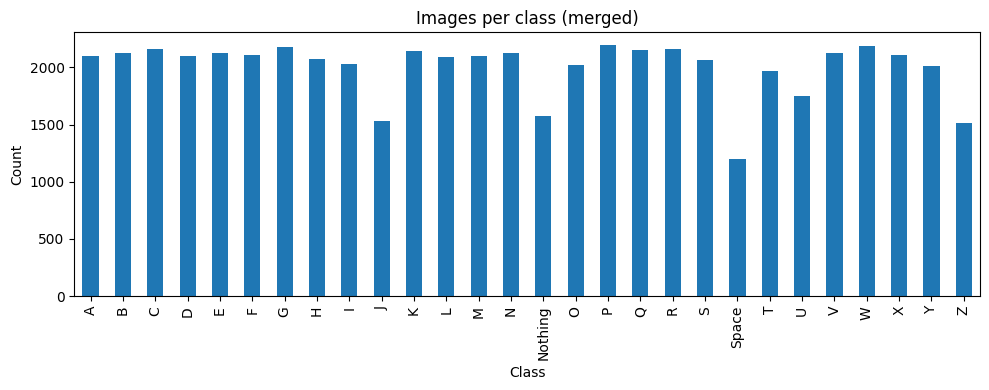

In [ ]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.DataFrame(all_pairs, columns=["filepath", "label", "source"])
counts = df["label"].value_counts().sort_index()
print("Classes found:", len(counts))
print(counts.head(30).to_string())

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.title("Images per class (merged)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The EDA shows the distribution of classes in the merged dataset. They are fairly balanced, but label J, Nothing, Space and Z have slightly lower representation.

# Transformation pipeline

In [ ]:
import numpy as np
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch

def compute_mean_std(sample_paths, max_samples=2000):
    acc = []
    for p in sample_paths[:max_samples]:
        try:
            im = Image.open(p).convert("RGB")
            im = im.resize(image_size)
            arr = (torch.tensor(np.array(im), dtype=torch.float32) / 255.0).permute(2,0,1)
            acc.append(arr)
        except Exception:
            continue
    if not acc:
        return [0.485,0.456,0.406], [0.229,0.224,0.225]
    stacked = torch.stack(acc, dim=0)
    mean = stacked.mean(dim=(0,2,3)).tolist()
    std = stacked.std(dim=(0,2,3)).tolist()
    return mean, std

mean, std = compute_mean_std([p for p,_,_ in all_pairs])
print("Using mean,std:", mean, std)

train_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomResizedCrop(image_size, scale=(0.8,1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_test_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

class MergedImageDataset(Dataset):
    def __init__(self, entries, label_to_idx, transform=None, use_rgb=True):
        self.entries = entries
        self.label_to_idx = label_to_idx
        self.transform = transform
        self.use_rgb = use_rgb
    def __len__(self): return len(self.entries)
    def __getitem__(self, idx):
        path, label, src = self.entries[idx]
        try:
            img = Image.open(path).convert("RGB")
        except:
            print(f"BAD IMAGE: {path}")
            return torch.zeros(3,128,128), label
        if self.transform: 
            img = self.transform(img)
        return img, self.label_to_idx[label]



Using mean,std: [0.562156081199646, 0.5304652452468872, 0.5140662789344788] [0.10339982062578201, 0.1647106260061264, 0.1853148639202118]


We computed mean and std for our merged dataset and used them for normalization in our transformation pipeline.

# Dataset split

In [ ]:
from sklearn.model_selection import train_test_split
entries = all_pairs.copy()
labels_array = [label_to_idx[l] for _, l, _ in entries]

train_entries, temp_entries, y_train, y_temp = train_test_split(
    entries, labels_array, test_size=(1-train_frac), random_state=hyperparams["random_seed"],
    stratify=labels_array if labels_array else None
)

if len(temp_entries) > 0:
    rel_val = val_frac / (val_frac + test_frac)
    temp_labels = [label_to_idx[l] for _, l, _ in temp_entries]
    val_entries, test_entries, y_val, y_test = train_test_split(
        temp_entries, temp_labels, test_size=(1-rel_val), random_state=hyperparams["random_seed"],
        stratify=temp_labels if temp_labels else None
    )
else:
    val_entries = []; test_entries = []

print("Split:", len(train_entries), len(val_entries), len(test_entries))

train_ds = MergedImageDataset(train_entries, label_to_idx, transform=train_transform, use_rgb=use_rgb)
val_ds = MergedImageDataset(val_entries, label_to_idx, transform=val_test_transform, use_rgb=use_rgb)
test_ds = MergedImageDataset(test_entries, label_to_idx, transform=val_test_transform, use_rgb=use_rgb)

train_loader = DataLoader(train_ds, batch_size=hyperparams["batch_size"], shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=hyperparams["batch_size"], shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=hyperparams["batch_size"], shuffle=False, num_workers=0, pin_memory=False)

Splits: 39205 8401 8402


# Model Class

In [8]:
# -----------------------
# Model (easy to replace)
# -----------------------
import torch.nn as nn, torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes, input_channels=3):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels,32,3,padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64,128,3,padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        h,w = image_size
        flattened = (h//8)*(w//8)*128
        self.fc1 = nn.Linear(flattened,256)
        self.fc2 = nn.Linear(256,num_classes)
        self.dropout = nn.Dropout(0.4)
    def forward(self,x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

num_classes = len(label_to_idx)
model = SimpleCNN(num_classes=num_classes, input_channels=3 if use_rgb else 1).to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=8192, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=28, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
)


Easy to modify model class for future experiments. We use a simple CNN with 3 convolutional layers followed by 2 fully connected layers. We used adam optimizer and cross entropy loss.

In [ ]:
import copy, torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=hyperparams["learning_rate"],
    weight_decay=hyperparams["weight_decay"]
)

# 1) Cosine decay (smooth, good default)
#scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=hyperparams["num_epochs"])

# 2) Step decay (drops LR every few epochs)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

for epoch in range(hyperparams["num_epochs"]):
    print(f"Epoch {epoch+1}/{hyperparams['num_epochs']}")
    model.train()
    running_loss = 0.0; running_corrects = 0; total = 0

    for inputs, labels in tqdm(train_loader, desc="Train batches"):
        inputs = inputs.to(device); labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data).item()
        total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    print(f"Train loss: {epoch_loss:.4f} acc: {epoch_acc:.4f}")

    model.eval()
    val_loss = 0.0; val_corrects = 0; vtotal = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device); labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data).item()
            vtotal += inputs.size(0)

    val_loss /= vtotal
    val_acc = val_corrects / vtotal
    print(f"Val  loss: {val_loss:.4f} acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), hyperparams["save_model_path"])
        print("Saved best model.")

    #scheduler.step()

    history["train_loss"].append(epoch_loss)
    history["train_acc"].append(epoch_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(optimizer.param_groups[0]["lr"])

print(f"Training complete. Best val acc: {best_acc:.4f}")
model.load_state_dict(best_model_wts)


Epoch 1/60


Train batches: 100%|██████████| 613/613 [06:04<00:00,  1.68it/s]


Train loss: 2.5329 acc: 0.2222
Val  loss: 1.5207 acc: 0.5404
Saved best model.
Epoch 2/60


Train batches: 100%|██████████| 613/613 [04:45<00:00,  2.14it/s]


Train loss: 1.8699 acc: 0.3843
Val  loss: 1.2689 acc: 0.6167
Saved best model.
Epoch 3/60


...

Train batches: 100%|██████████| 613/613 [04:56<00:00,  2.07it/s]


Train loss: 0.0868 acc: 0.9730
Val  loss: 0.0385 acc: 0.9895
Epoch 60/60


Train batches: 100%|██████████| 613/613 [04:56<00:00,  2.07it/s]


Train loss: 0.0871 acc: 0.9737
Val  loss: 0.0318 acc: 0.9908
Saved best model.
Training complete. Best val acc: 0.9908


<All keys matched successfully>

This model we trained for 5h. The train and validation loss and accuracy are shown in the plots below. The model achieves a good accuracy on the validation set, indicating that it has learned to generalize well to unseen data.

# Plot results

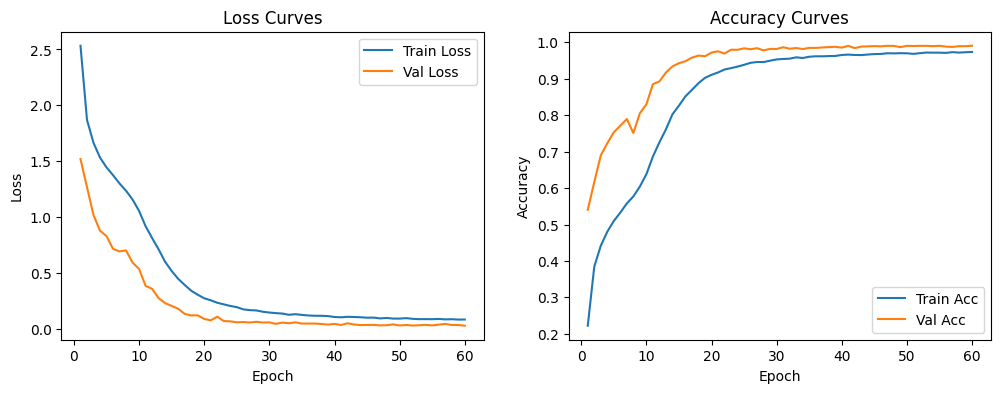

In [ ]:
epochs = range(1, hyperparams["num_epochs"] + 1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Loss Curves"); plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Accuracy Curves"); plt.legend()

plt.show()

# Testing the best model

              precision    recall  f1-score   support

           A       0.99      1.00      1.00       315
           B       1.00      0.99      0.99       319
           C       0.99      0.99      0.99       324
           D       0.99      0.99      0.99       315
           E       1.00      0.99      0.99       319
           F       1.00      0.99      1.00       317
           G       0.99      0.98      0.99       326
           H       0.98      1.00      0.99       312
           I       1.00      1.00      1.00       304
           J       1.00      0.99      0.99       229
           K       1.00      0.98      0.99       322
           L       0.99      1.00      1.00       314
           M       0.99      0.98      0.99       315
           N       0.98      1.00      0.99       319
     Nothing       0.99      0.99      0.99       236
           O       0.97      0.99      0.98       303
           P       0.98      1.00      0.99       330
           Q       0.99    

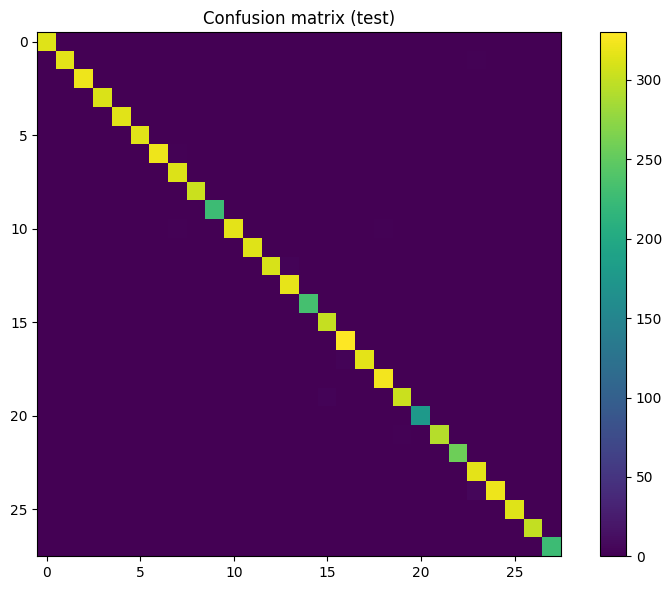

Saved label_mapping.json


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
model.eval()
y_true = []; y_pred = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs); _, preds = torch.max(outputs, 1)
        y_true.extend(labels.numpy().tolist()); y_pred.extend(preds.cpu().numpy().tolist())

if y_true:
    print(classification_report(y_true, y_pred, target_names=[idx_to_label[i] for i in sorted(idx_to_label)], zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=list(sorted(idx_to_label.keys())))
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8,6)); plt.imshow(cm); plt.title("Confusion matrix (test)"); plt.colorbar(); plt.tight_layout(); plt.show()
else:
    print("No test samples to evaluate.")

import json
with open("label_mapping.json","w") as f:
    json.dump({"idx_to_label": idx_to_label, "label_to_idx": label_to_idx}, f)
print("Saved label_mapping.json")

# Expreimenting

Our initial approach to training the model was to use grayscale images to reduce complexity. However, after some testing and consideration, we decided to switch to RGB images, as they provide more information for the model to learn from and can improve accuracy in real-world applications.

We started with simple models that did not use weight decay and an image size of 128×128. The results were promising, but we later reduced the image size to 64×64 to speed up training. We also introduced weight decay to help prevent overfitting. Although weight decay did not have a significant impact, it slightly improved F1 score and recall, but training took longer.

We experimented with different learning rates as well. Using a learning rate of 0.05 caused the model to diverge, resulting in higher loss and lower accuracy after a few epochs. We then tried a learning rate of 0.01, but the results were still unsatisfactory. Ultimately, we returned to the original learning rate of 0.001, which worked well with the Adam optimizer. We did not experiment with different optimizers, loss functions, or activation functions, as there was no need to make such changes from the beginning.

Initially, we trained the models for a smaller number of epochs to get a sense of their performance. In the end, we settled on 60 epochs, which gave the model sufficient time to learn. This configuration was successful, and as seen in the classification report, the model performed quite well.

We also prepared a live sign classification setup, which works but requires more testing and tuning to achieve faster and more accurate results. The main limitation we observed is that resizing the images to 64×64 may reduce the variety and detail available to the model.

Overall, we found that our initial configuration was effective and required minimal tuning.